In [31]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder, OrdinalEncoder
import os

In [5]:
db = duckdb.from_csv_auto('/Volumes/T7/IDX_data/CRMLSSold202506.csv').to_df()

In [6]:
db

,BuyerAgentAOR,ListAgentAOR,Flooring,ViewYN,WaterfrontYN,BasementYN,PoolPrivateYN,OriginalListPrice,ListingKey,ListAgentEmail,...,LotSizeDimensions,LotSizeArea,MainLevelBedrooms,NewConstructionYN,GarageSpaces,HighSchoolDistrict,PostalCode,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict
0,SanDiego,SanDiego,None,False,<NA>,<NA>,False,5000.0,542181398,ops@downtowncondoguys.com,...,None,NaN,NaN,<NA>,1.0,None,92101,0.0,NaN,None
1,PacificWest,PacificWest,None,True,<NA>,<NA>,<NA>,110000.0,540760713,nowjoanne@gmail.com,...,None,355936.0,NaN,False,NaN,None,93550,0.0,355936.0,None
2,SouthwestLosAngeles,SouthwestLosAngeles,None,True,<NA>,<NA>,<NA>,1545000.0,525608302,Austin_Brown@pacificplayarealty.com,...,88x231,20212.0,NaN,False,NaN,None,90008,NaN,20212.0,None
3,TheInlandGateway,TheInlandGateway,None,True,<NA>,<NA>,False,889000.0,523319952,hutton@cbappteam.com,...,None,9600.0,0.0,True,2.0,Rim of the World,92352,0.0,9600.0,None
4,SanDiego,SanDiego,Laminate,True,<NA>,<NA>,False,1700.0,518730969,mannybehar@yahoo.com,...,None,NaN,NaN,<NA>,0.0,None,92126,0.0,NaN,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22878,Mlslistings,Mlslistings,None,False,<NA>,<NA>,<NA>,36900000.0,1019048995,btanger@intero.com,...,None,515314.8,NaN,<NA>,NaN,Other,95070,NaN,515314.8,None
22879,WestSanGabrielValley,WestSanGabrielValley,None,True,<NA>,<NA>,True,9180000.0,1018931071,sostlund@lee-assoc.com,...,None,174240.0,5.0,False,4.0,Capistrano Unified,92679,695.0,174240.0,None
22880,Mlslistings,Mlslistings,None,False,<NA>,<NA>,<NA>,349000.0,1016273554,sara@coastalcahomes.com,...,None,138521.0,NaN,<NA>,NaN,Other,93907,214.0,138521.0,None
22881,OrangeCounty,OrangeCounty,"Stone,Wood",True,<NA>,<NA>,False,17000.0,1014281750,Leeann@canadaygroup.com,...,None,5950.0,1.0,False,2.0,Laguna Beach Unified,92651,0.0,5950.0,None


In [17]:
db.describe()

,OriginalListPrice,ListingKey,CloseDate,ClosePrice,Latitude,Longitude,LivingArea,ListPrice,DaysOnMarket,ListingKeyNumeric,...,ContractStatusChangeDate,PurchaseContractDate,ListingContractDate,BelowGradeFinishedArea,Stories,LotSizeArea,MainLevelBedrooms,GarageSpaces,AssociationFee,LotSizeSquareFeet
count,2.281100e+04,2.288300e+04,22883,2.288300e+04,22879.000000,22880.000000,21308.000000,2.284800e+04,22883.000000,2.288300e+04,...,22883,22443,22882,110.000000,18732.00000,2.106300e+04,12364.000000,19916.000000,15665.000000,2.104100e+04
mean,8.973742e+05,1.109938e+09,2025-06-15 05:17:54.981427,8.922487e+05,34.548733,-118.458038,1825.190867,8.619410e+05,41.476992,1.109938e+09,...,2025-06-15 05:17:54.981427,2025-05-19 17:36:26.178318,2025-04-01 02:50:59.103225,55.609091,1.37177,5.234909e+04,1.902378,1.778721,177.400540,4.638715e+05
min,0.000000e+00,4.218253e+08,2025-06-01 00:00:00,0.000000e+00,0.000000,-156.450320,0.000000,1.400000e+00,-26.000000,4.218253e+08,...,2025-06-01 00:00:00,2021-07-25 00:00:00,2015-05-15 00:00:00,0.000000,1.00000,0.000000e+00,0.000000,0.000000,0.000000,0.000000e+00
25%,4.750000e+04,1.109110e+09,2025-06-09 00:00:00,4.000000e+04,33.733862,-118.561905,1184.000000,4.737500e+04,9.000000,1.109110e+09,...,2025-06-09 00:00:00,2025-05-09 00:00:00,2025-03-19 00:00:00,0.000000,1.00000,5.009500e+03,1.000000,1.000000,0.000000,5.227000e+03
50%,6.490000e+05,1.112153e+09,2025-06-16 00:00:00,6.315000e+05,34.041916,-118.055588,1595.000000,6.380000e+05,22.000000,1.112153e+09,...,2025-06-16 00:00:00,2025-05-22 00:00:00,2025-04-22 00:00:00,0.000000,1.00000,7.207000e+03,2.000000,2.000000,0.000000,7.405000e+03
75%,1.100000e+06,1.113861e+09,2025-06-23 00:00:00,1.100000e+06,34.393690,-117.330082,2185.250000,1.099000e+06,50.000000,1.113861e+09,...,2025-06-23 00:00:00,2025-06-04 00:00:00,2025-05-12 00:00:00,0.000000,2.00000,1.219700e+04,3.000000,2.000000,283.000000,1.361100e+04
max,2.395000e+08,1.118608e+09,2025-06-30 00:00:00,9.000000e+08,45.772309,121.116478,39111.000000,6.800000e+07,1265.000000,1.118608e+09,...,2025-06-30 00:00:00,2025-06-30 00:00:00,2025-06-30 00:00:00,2000.000000,2.00000,2.831400e+08,34.000000,500.000000,8063.000000,2.090880e+09
std,2.331296e+06,1.438173e+07,NaN,6.084893e+06,1.651760,3.917697,1164.276153,1.394472e+06,62.518260,1.438173e+07,...,NaN,NaN,NaN,252.155300,0.48329,2.020131e+06,1.435027,4.649280,340.986858,2.056782e+07


Key features:
- ListingKey is ID
- Target? OriginalListPrice or ListPrice or ClosePrice?

Issues:
- NaN values coded inconsistent
- Possible invalid values in ParkingTotal, DaysOnMarket
- ListPrice not available for 35 houses (drop or impute?)

Notes: PropertyType="Residential" and PropertySubType="SingleFamilyResidence"

In [18]:
db['PropertyType'].value_counts()

PropertyType
Residential            15329
ResidentialLease        5376
Land                     706
ManufacturedInPark       638
ResidentialIncome        571
CommercialSale           135
CommercialLease          112
BusinessOpportunity       16
Name: count, dtype: int64

# Data Ingestion

In [2]:
conn = duckdb.connect('CRMLS.db')

In [3]:
conn.query(
    """
    CREATE TABLE IF NOT EXISTS Property AS
    SELECT *, regexp_extract(filename, 'CRMLSSold(\\d{6})\\.csv$', 1) AS ReadDate
    FROM read_csv_auto('/Volumes/T7/IDX_data/CRMLSSold2025*.csv', filename=True)
    """
)

NameError: name 'conn' is not defined

In [121]:
df = conn.query(
    """
    SELECT * FROM Property WHERE PropertyType = 'Residential' AND PropertySubType = 'SingleFamilyResidence'
    """
).to_df()

In [122]:
df.columns.sort_values()

Index(['AboveGradeFinishedArea', 'AssociationFee', 'AssociationFeeFrequency',
       'AttachedGarageYN', 'BasementYN', 'BathroomsTotalInteger',
       'BedroomsTotal', 'BelowGradeFinishedArea', 'BuilderName',
       'BuildingAreaTotal', 'BusinessType', 'BuyerAgentAOR',
       'BuyerAgentFirstName', 'BuyerAgentLastName', 'BuyerAgentMlsId',
       'BuyerOfficeAOR', 'BuyerOfficeName', 'City', 'CloseDate', 'ClosePrice',
       'CoBuyerAgentFirstName', 'CoListAgentFirstName', 'CoListAgentLastName',
       'CoListOfficeName', 'ContractStatusChangeDate', 'CountyOrParish',
       'CoveredSpaces', 'DaysOnMarket', 'ElementarySchool',
       'ElementarySchoolDistrict', 'FireplaceYN', 'FireplacesTotal',
       'Flooring', 'GarageSpaces', 'HighSchool', 'HighSchoolDistrict',
       'Latitude', 'Levels', 'ListAgentAOR', 'ListAgentEmail',
       'ListAgentFirstName', 'ListAgentFullName', 'ListAgentLastName',
       'ListOfficeName', 'ListPrice', 'ListingContractDate', 'ListingId',
       'ListingKey',

In [123]:
df.describe()

,OriginalListPrice,ListingKey,CloseDate,ClosePrice,Latitude,Longitude,LivingArea,ListPrice,DaysOnMarket,ListingKeyNumeric,...,ContractStatusChangeDate,PurchaseContractDate,ListingContractDate,BelowGradeFinishedArea,Stories,LotSizeArea,MainLevelBedrooms,GarageSpaces,AssociationFee,LotSizeSquareFeet
count,1.167400e+04,1.170100e+04,11701,1.170100e+04,11700.000000,11700.000000,11691.000000,1.170100e+04,11701.000000,1.170100e+04,...,11701,11700,11701,78.000000,10380.000000,1.150800e+04,6979.000000,11213.000000,8150.000000,1.150500e+04
mean,1.358763e+06,1.110248e+09,2025-06-15 10:55:12.332279,1.372109e+06,34.780331,-118.660771,2063.597554,1.303013e+06,35.140843,1.110248e+09,...,2025-06-15 10:55:12.332279,2025-05-14 16:45:32.307692,2025-04-01 22:51:12.352790,70.615385,1.365800,1.785212e+04,2.258920,2.075047,102.273492,1.753748e+05
min,4.800000e+02,5.233200e+08,2025-06-01 00:00:00,3.500000e+04,1.000000,-123.812245,0.000000,3.500000e+04,-26.000000,5.233200e+08,...,2025-06-01 00:00:00,2021-12-19 00:00:00,2021-06-20 00:00:00,0.000000,1.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000e+00
25%,6.471300e+05,1.109192e+09,2025-06-09 00:00:00,6.350000e+05,33.764077,-119.498154,1399.000000,6.350000e+05,8.000000,1.109192e+09,...,2025-06-09 00:00:00,2025-05-07 00:00:00,2025-03-18 00:00:00,0.000000,1.000000,5.500000e+03,1.000000,2.000000,0.000000,5.672000e+03
50%,9.100000e+05,1.112090e+09,2025-06-16 00:00:00,9.100000e+05,34.096701,-118.052362,1836.000000,8.999000e+05,18.000000,1.112090e+09,...,2025-06-16 00:00:00,2025-05-18 00:00:00,2025-04-19 00:00:00,0.000000,1.000000,7.200000e+03,3.000000,2.000000,0.000000,7.400000e+03
75%,1.495000e+06,1.113014e+09,2025-06-23 00:00:00,1.475000e+06,35.112452,-117.265153,2450.000000,1.468800e+06,44.000000,1.113014e+09,...,2025-06-23 00:00:00,2025-05-28 00:00:00,2025-05-08 00:00:00,0.750000,2.000000,1.008000e+04,3.000000,2.000000,132.000000,1.056600e+04
max,2.395000e+08,1.118606e+09,2025-06-30 00:00:00,9.000000e+08,41.894714,117.310000,30500.000000,6.800000e+07,644.000000,1.118606e+09,...,2025-06-30 00:00:00,2025-06-30 00:00:00,2025-06-30 00:00:00,2000.000000,2.000000,1.307236e+07,34.000000,500.000000,8063.000000,8.872301e+08
std,3.083604e+06,8.380990e+06,NaN,8.450104e+06,1.746066,3.104814,1069.492857,1.678658e+06,47.518227,8.380990e+06,...,NaN,NaN,NaN,291.025961,0.481677,1.433545e+05,1.438384,6.095689,284.203833,9.417322e+06


In [124]:
df.groupby(['Latitude', 'Longitude'])['Latitude'].count().sum() - df['ListingKey'].nunique()


np.int64(0)

Confirmed alignment and uniqueness of key

# Missing values identification

## Populate DB with all training data

In [67]:
conn.close()

In [68]:
training_months = range(6, 13)
conn = duckdb.connect('CRMLS.db')
path = '/Volumes/T7/IDX_data/'
files = [f for f in os.listdir(path) if not f.startswith('.')]

conn.query(
    f"""
    CREATE TABLE IF NOT EXISTS Property AS
    SELECT
        * EXCLUDE (filename),
        strptime(regexp_extract(filename, 'CRMLSSold(\\d{{6}})\\.csv$', 1), '%Y%m')::DATE AS ReadDate
    FROM read_csv_auto('/Volumes/T7/IDX_data/{files[0]}', filename = True, nullstr = ['NaN','nan','N/A','NA','', 'NULL'])
    """
)
#
# test = conn.query(
#     """
#     SELECT *
#     FROM Property
#     WHERE
#         PropertyType = 'Residential' AND
#         PropertySubType = 'SingleFamilyResidence'
#     """
# ).to_df()



# conn.query(
#     """
#     ALTER TABLE Property
#         ADD CONSTRAINT PK_ListingId PRIMARY KEY (ListingId, MlsStatus)
#     """
# )

for n in range(1, len(files)):
    conn.query(
        f"""
    INSERT INTO Property
    SELECT
        * EXCLUDE (filename),
        strptime(regexp_extract(filename, 'CRMLSSold(\\d{{6}})\\.csv$', 1), '%Y%m')::DATE AS ReadDate
    FROM read_csv_auto('/Volumes/T7/IDX_data/{files[n]}', filename = True, nullstr = ['NaN','nan','N/A','NA','', 'NULL'])
    """
    )


In [69]:
def column_na_plot(data: pd.DataFrame):
    is_na = []
    for column in data.columns:
        is_na.append(data[column].isna().sum() * 100 / len(df[column]))
    plt.figure(figsize = (20,10))
    plt.bar(x=data.columns, height=is_na)
    plt.xticks(rotation=90)
    plt.xlabel('Columns')
    plt.ylabel('% Missing Values')
    plt.title('Percentage of Missing Values in each column')
    plt.show()

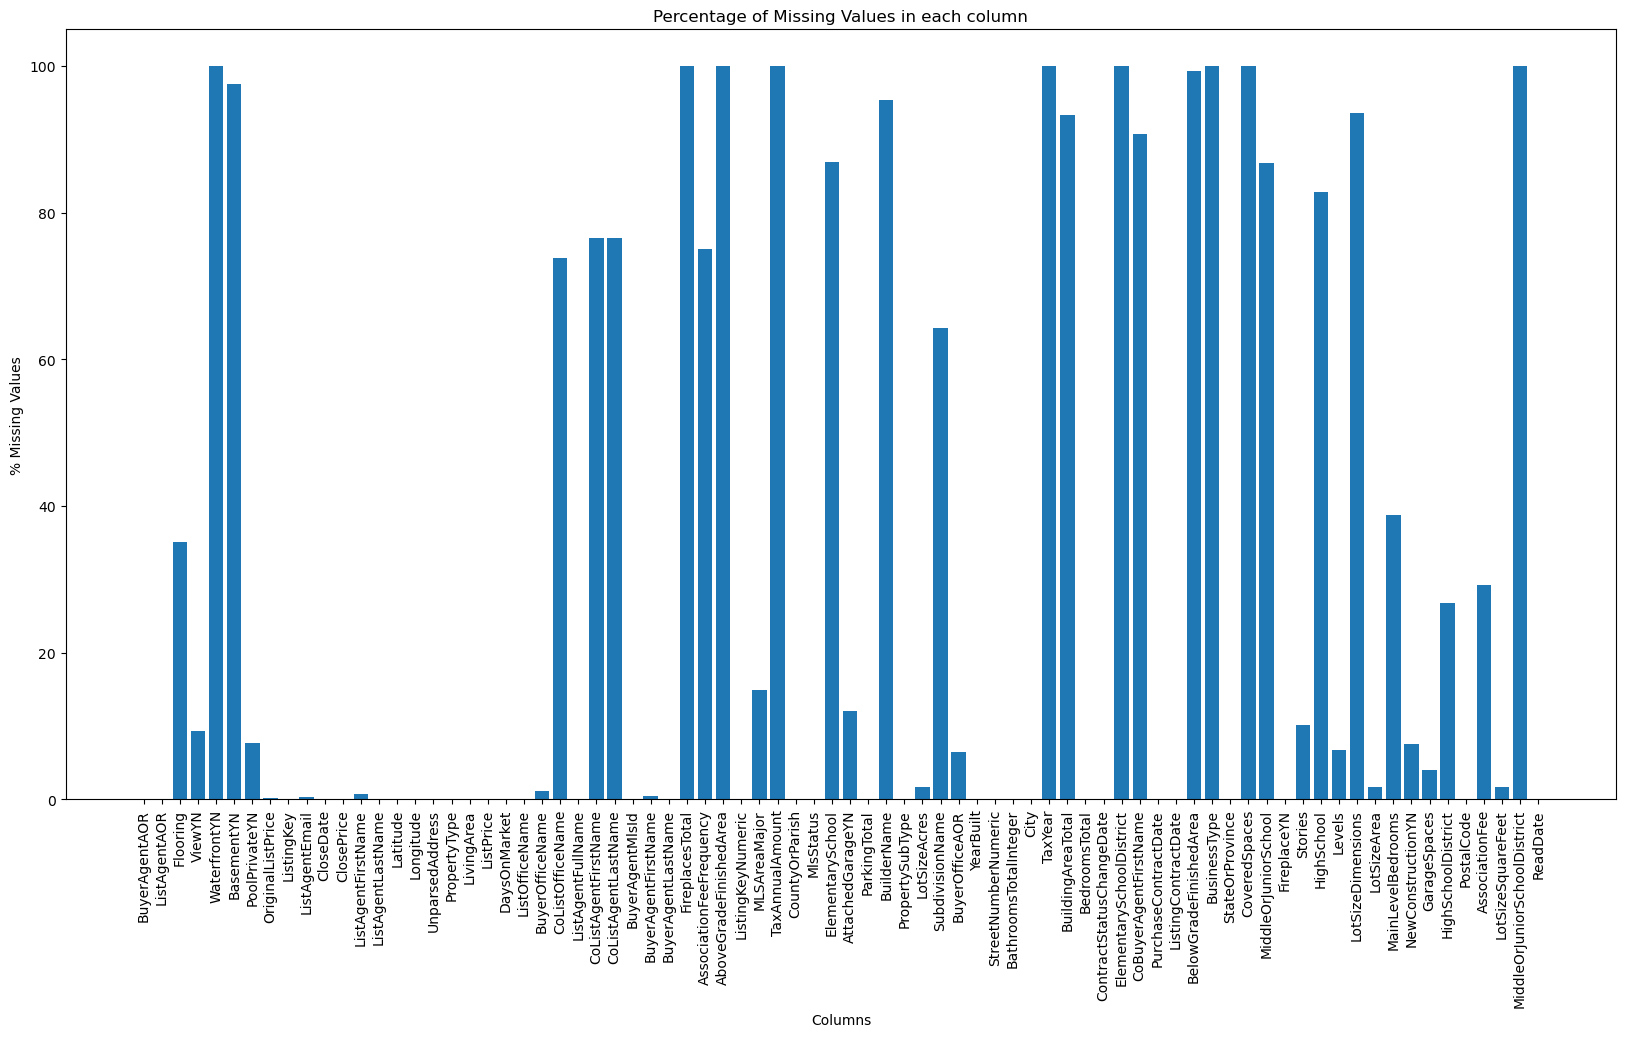

In [91]:
df = conn.query(
    """
    SELECT *
    FROM Property
    WHERE
        PropertyType = 'Residential' AND
        PropertySubType = 'SingleFamilyResidence'
    """
).to_df(date_as_object=True)
df.set_index('ListingId', inplace=True)
is_na_count = []
for column in df.columns:
        is_na_count.append(df[column].isna().sum() * 100 / len(df[column]))

column_na_plot(df)

For columns with > 50% NaNs, dropping the whole columns

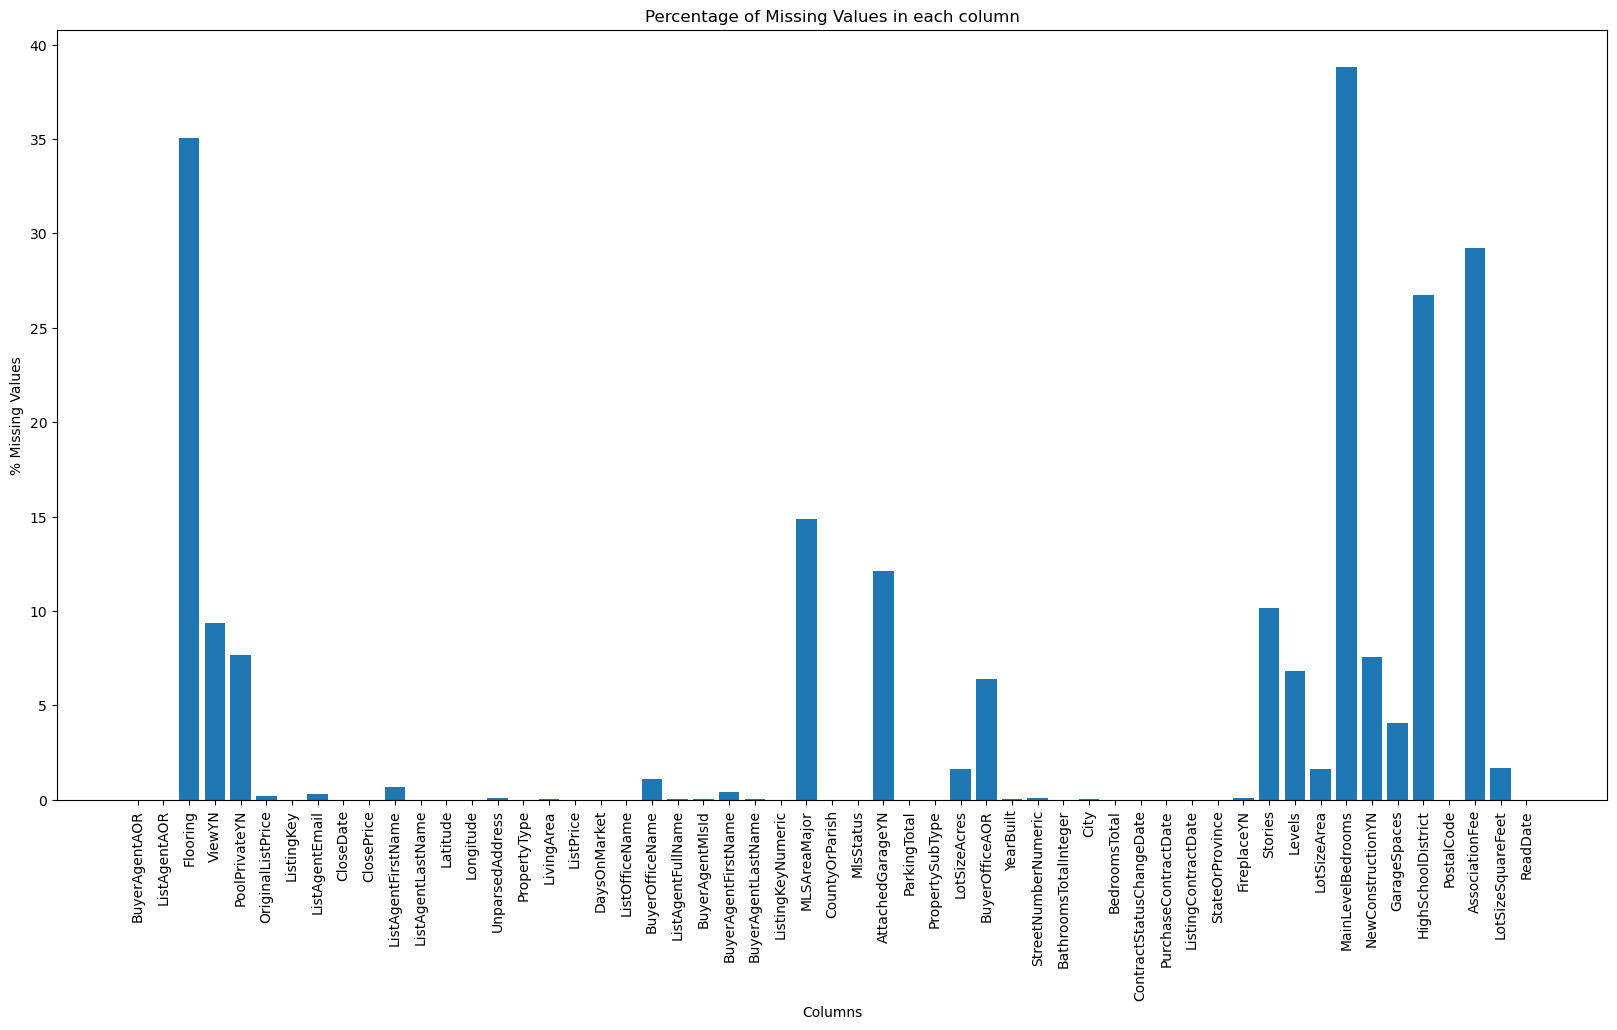

In [92]:
i = len(is_na_count) - 1
dropped_columns = []
while i >= 0:
    na_count = is_na_count[i]
    if na_count > 50:
        dropped_columns.append(df.columns[i])
        df.drop(df.columns[i], axis=1, inplace=True)
        is_na_count.pop(i)
    i -= 1

column_na_plot(df)
# len(df.columns)

In [93]:
na_columns = df.columns[df.isna().sum() > 0].tolist()
print(na_columns)

['BuyerAgentAOR', 'ListAgentAOR', 'Flooring', 'ViewYN', 'PoolPrivateYN', 'OriginalListPrice', 'ListAgentEmail', 'ListAgentFirstName', 'ListAgentLastName', 'Latitude', 'Longitude', 'UnparsedAddress', 'LivingArea', 'BuyerOfficeName', 'ListAgentFullName', 'BuyerAgentMlsId', 'BuyerAgentFirstName', 'BuyerAgentLastName', 'MLSAreaMajor', 'AttachedGarageYN', 'ParkingTotal', 'LotSizeAcres', 'BuyerOfficeAOR', 'YearBuilt', 'StreetNumberNumeric', 'BathroomsTotalInteger', 'City', 'PurchaseContractDate', 'FireplaceYN', 'Stories', 'Levels', 'LotSizeArea', 'MainLevelBedrooms', 'NewConstructionYN', 'GarageSpaces', 'HighSchoolDistrict', 'PostalCode', 'AssociationFee', 'LotSizeSquareFeet']


In [94]:
print(dropped_columns[:])

['MiddleOrJuniorSchoolDistrict', 'LotSizeDimensions', 'HighSchool', 'MiddleOrJuniorSchool', 'CoveredSpaces', 'BusinessType', 'BelowGradeFinishedArea', 'CoBuyerAgentFirstName', 'ElementarySchoolDistrict', 'BuildingAreaTotal', 'TaxYear', 'SubdivisionName', 'BuilderName', 'ElementarySchool', 'TaxAnnualAmount', 'AboveGradeFinishedArea', 'AssociationFeeFrequency', 'FireplacesTotal', 'CoListAgentLastName', 'CoListAgentFirstName', 'CoListOfficeName', 'BasementYN', 'WaterfrontYN']


## Check importance of remaining columns with NaNs

- Listing agent's name parts will be dropped and Id will be utilized to remove redundancy. However, need to compare predictive power to ListAgenAOR to see if it is needed to go in details.
- BuyerAgents information will be discarded as we can't judge people behavior based on their name.
- MainLevelBedroom is dropped due to redundancy and high missingness
- AssociationFees can be imputed with 0 to indicate the property doesn't have HOA fees.
- Drop ListingPrice and OriginalListingPrice per instructions from Aidan
- Drop ListingId fields to reduce overfit.
- Drop MLSStatus as it only contain Closed status
- Drop ListingContractDate and ContractChangeDate as the focus is in close price and DaysOnMarket already contain the necessary info.
- Drop all geographic features to remove redundancy to ZIP code


In [95]:
for column in df.columns:
    if ("uyer" in column) or ("Name" in column):
        df.drop(column, axis=1, inplace=True)
df.drop(['MainLevelBedrooms', 'AssociationFee', 'ListPrice', 'OriginalListPrice', 'PropertyType', 'PropertySubType', 'ListingKey', 'ListingKeyNumeric', 'PurchaseContractDate', 'MlsStatus', 'UnparsedAddress', 'StreetNumberNumeric', 'City', 'StateOrProvince'], axis=1, inplace=True)

In [96]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 78948 entries, EV21134678 to IG20153137
Data columns (total 31 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ListAgentAOR              78936 non-null  object 
 1   Flooring                  51269 non-null  object 
 2   ViewYN                    71561 non-null  boolean
 3   PoolPrivateYN             72888 non-null  boolean
 4   ListAgentEmail            78689 non-null  object 
 5   CloseDate                 78948 non-null  object 
 6   ClosePrice                78948 non-null  float64
 7   Latitude                  78942 non-null  float64
 8   Longitude                 78942 non-null  float64
 9   LivingArea                78905 non-null  float64
 10  DaysOnMarket              78948 non-null  int64  
 11  MLSAreaMajor              67192 non-null  object 
 12  CountyOrParish            78948 non-null  object 
 13  AttachedGarageYN          69375 non-null  boolean
 1

In [76]:
df.drop(['HighSchoolDistrict', 'MLSAreaMajor', 'Flooring', 'Stories', 'ListAgentEmail', 'ContractStatusChangeDate', 'ListingContractDate'], axis=1, inplace=True)

Questions:
- Is Listing agents info necessary?
- Does Zipcode alone sufficient to carry geographic info of the property or City + County + State (cannot encode quickly due to non-ordinal nature)?
- Is None in District mean property not in a school district? It has low availability, drop it?
- Should we use ContractListingDate as listing date? Is it necessary? (encode by cyclical feature)
- Should we use external inflation data?

Must imputation:
- LotSizeArea, LotSizeSquareFeet

Potential imputation:
- Levels / Stories

# Feature Engineer

In [97]:
def zipcode_parse(org: str):
    if org is not None:
        if len(org) >= 5:
            return org[:5]
        else:
            return 0
    else:
        return 0

In [102]:
df['PostalCode'] = df['PostalCode'].apply(zipcode_parse)
df = df[(df['ClosePrice']  < 2*10**8) & (df['ClosePrice'] is not None)  & (df['PostalCode'].astype(int) > 90000)]

# Imputation

Prepare imputation for base model

In [103]:
print(f'Mean: {df['ClosePrice'].mean()}')
print(f'Stdev: {df['ClosePrice'].std()}')

Mean: 1247710.8533579991
Stdev: 1665337.3522890976


In [104]:
from scipy.stats import norm

/Users/eddie/miniconda3/envs/houseML/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/eddie/miniconda3/envs/houseML/lib/python3.13/site-packages/numpy/_core/function_base.py:163: RuntimeWarning: invalid value encountered in multiply
  y *= step
/Users/eddie/miniconda3/envs/houseML/lib/python3.13/site-packages/numpy/_core/function_base.py:173: RuntimeWarning: invalid value encountered in add
  y += start


ValueError: supplied range of [-inf, 19.11356714051112] is not finite

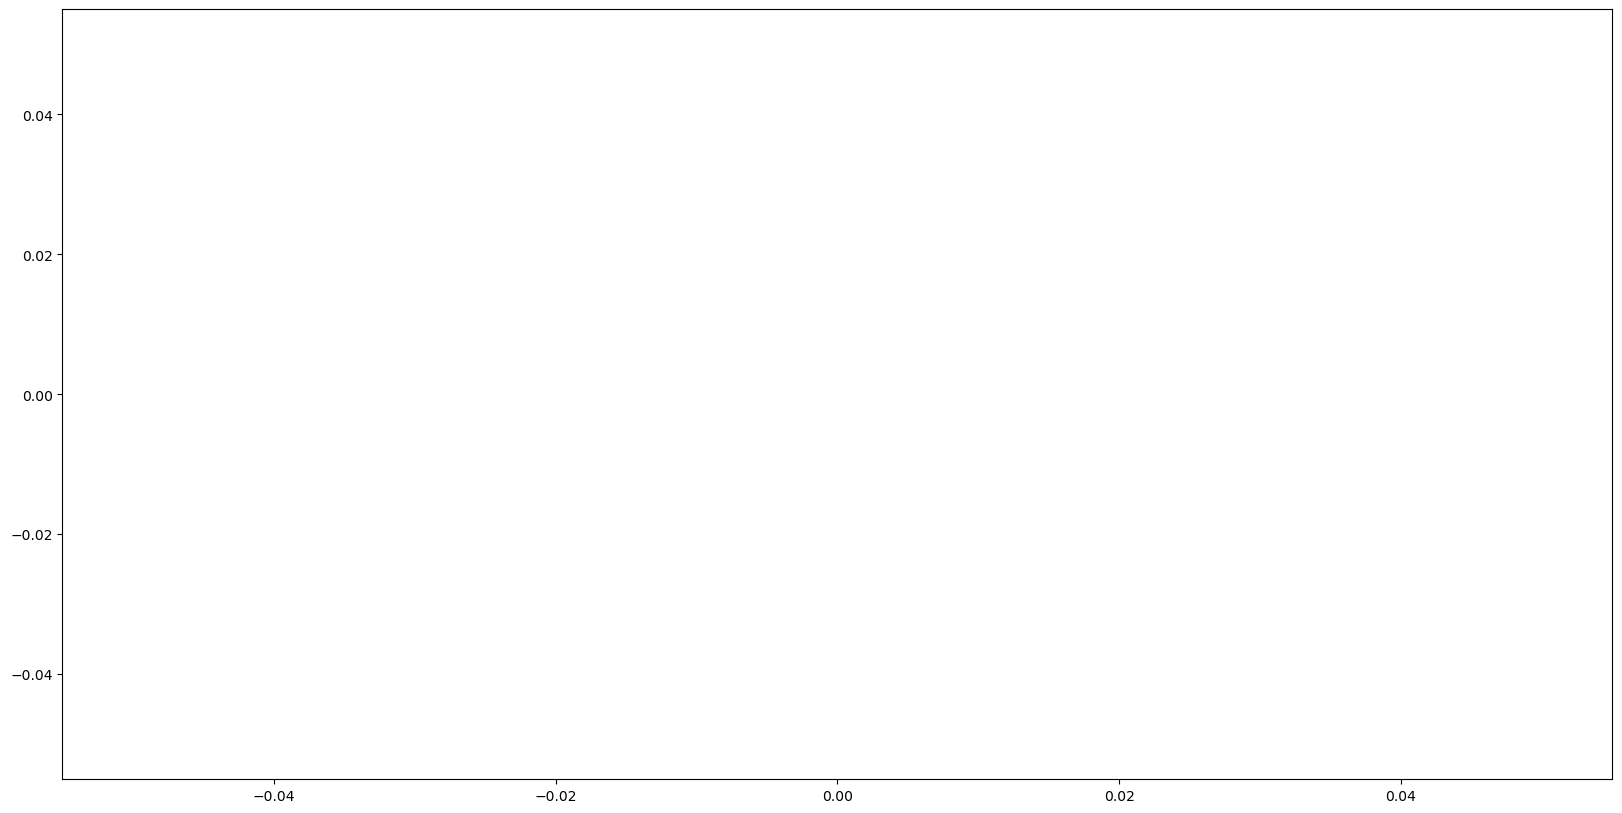

In [105]:
# Log price
logged_price = np.log(df['ClosePrice'])

fig = plt.figure(figsize = (20,10))
domain = np.linspace(np.min(logged_price), np.max(logged_price))
mu, sigma = np.mean(logged_price), np.std(logged_price, ddof=1)
normal_curve = norm.pdf(domain, mu, sigma)
plt.plot(domain, normal_curve, label='Normal')
plt.hist(logged_price, bins=50, label='Normal', alpha=0.5, density=True)
plt.axvline(x=mu, color='r', linestyle='dashed', linewidth=2)


# plt.show()

ClosePrice is Normal after logged

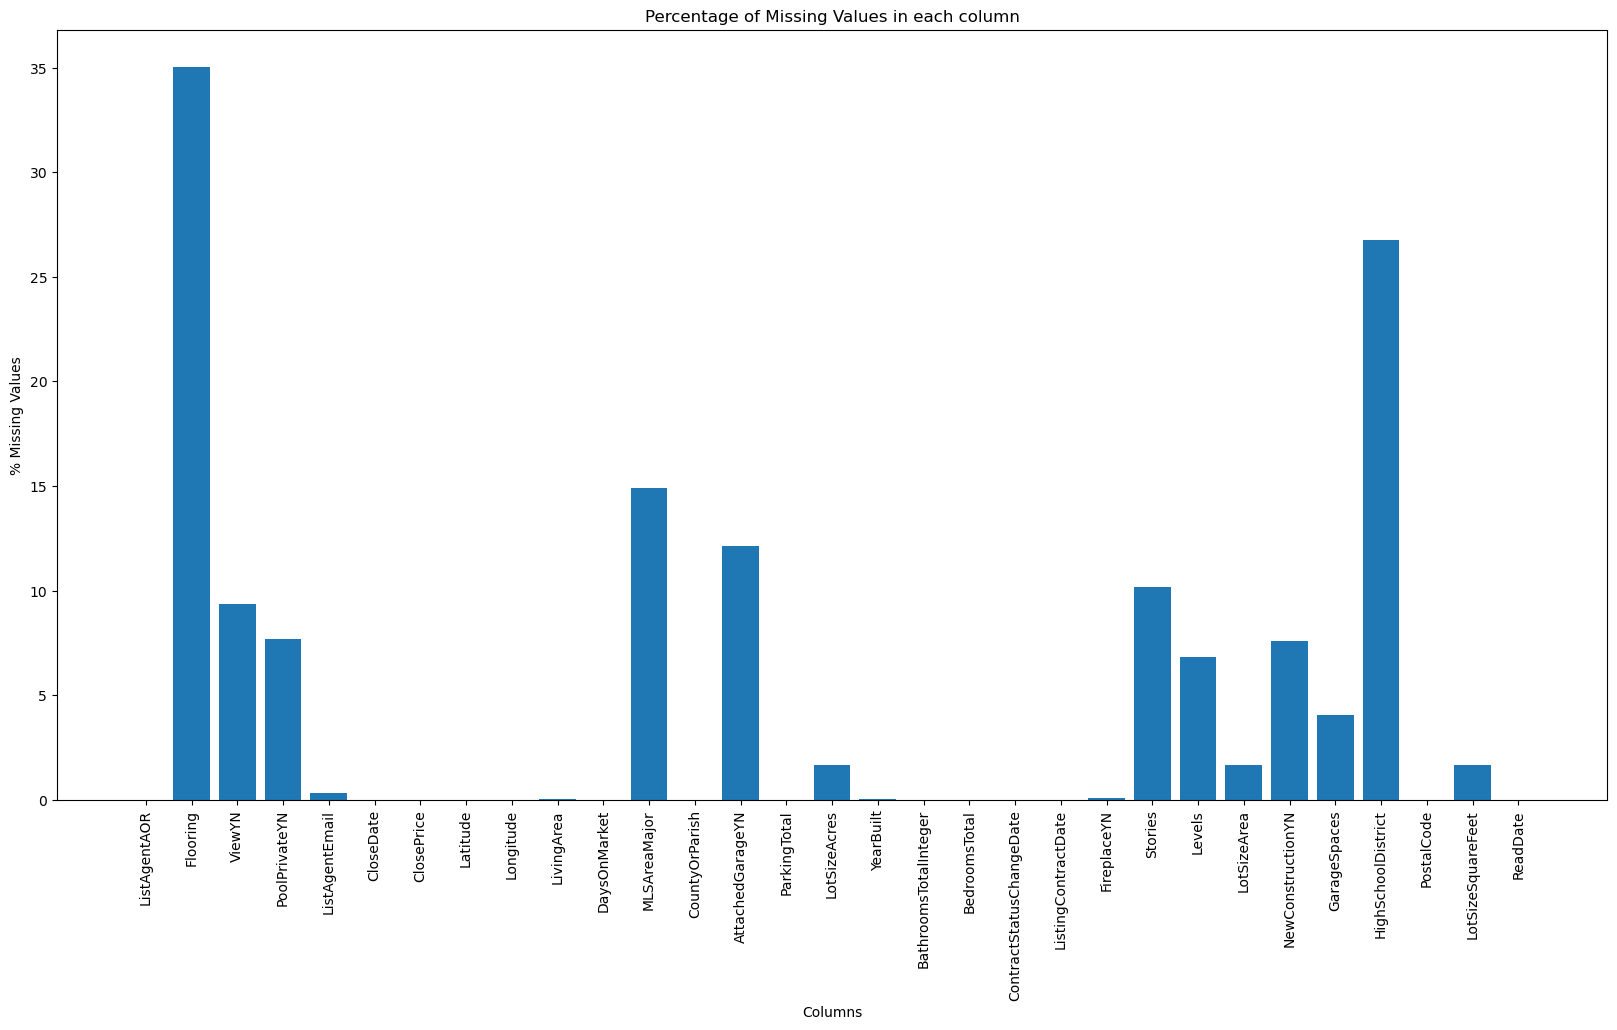

In [106]:
column_na_plot(df)

ValueError: cannot reindex on an axis with duplicate labels

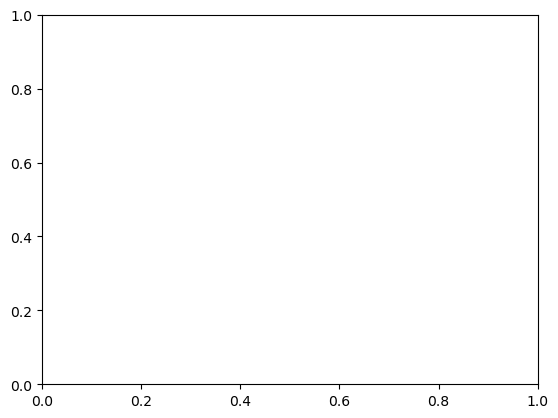

In [107]:
sns.scatterplot(
    data=df[df['ViewYN'].notnull()],
    x='Longitude',
    y='Latitude',
    hue='ViewYN',
)
plt.xlim(np.min(df['Longitude']), -110)
plt.ylim(30, np.max(df['Latitude']))

plt.show()

In [108]:
base_df = df[[column for column in df.columns if df[column].isna().sum() == 0]]
base_df

,CloseDate,ClosePrice,DaysOnMarket,CountyOrParish,BedroomsTotal,ContractStatusChangeDate,ListingContractDate,PostalCode,ReadDate
ListingId,,,,,,,,,
EV21134678,2025-06-13,890000.0,181,San Bernardino,3.0,2025-06-13,2021-06-20,92352,2025-06-01
25559373,2025-06-30,1876384.0,87,Los Angeles,3.0,2025-06-30,2025-04-04,90046,2025-06-01
ML82012939,2025-06-30,4820000.0,0,San Mateo,6.0,2025-06-30,2025-06-30,94010,2025-06-01
PW25146750,2025-06-30,865000.0,0,Orange,3.0,2025-06-30,2025-06-29,92886,2025-06-01
41103262,2025-06-30,875000.0,0,Alameda,3.0,2025-06-30,2025-06-30,94546,2025-06-01
...,...,...,...,...,...,...,...,...,...
GD23212467,2025-12-05,640000.0,171,Los Angeles,3.0,2025-12-05,2023-11-16,93551,2025-12-01
ML81923705,2025-12-04,12000000.0,755,Santa Clara,5.0,2025-12-04,2023-10-31,94301,2025-12-01
NS23056449,2025-12-17,600000.0,894,Monterey,3.0,2025-12-17,2023-04-11,93426,2025-12-01


In [109]:
base_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 78922 entries, EV21134678 to IG20153137
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   CloseDate                 78922 non-null  object 
 1   ClosePrice                78922 non-null  float64
 2   DaysOnMarket              78922 non-null  int64  
 3   CountyOrParish            78922 non-null  object 
 4   BedroomsTotal             78922 non-null  float64
 5   ContractStatusChangeDate  78922 non-null  object 
 6   ListingContractDate       78922 non-null  object 
 7   PostalCode                78922 non-null  object 
 8   ReadDate                  78922 non-null  object 
dtypes: float64(2), int64(1), object(6)
memory usage: 8.0+ MB


In [110]:
np.sin(2 * np.pi * (df['CloseDate'].dt.month/12.0))

AttributeError: Can only use .dt accessor with datetimelike values